In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("C:/Users/Krutarth0911/Downloads/all_MOFs_screening_data.csv")
df.head
print(df.shape)
print(df.columns)


(324426, 42)
Index(['MOFname', 'CO2_uptake_P0.15bar_T298K [mmol/g]',
       'CO2_uptake_error_P0.15bar_T298K [mmol/g]',
       'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]',
       'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]',
       'excess_CO2_uptake_P0.15bar_T298K [mmol/g]',
       'CO2_uptake_P0.10bar_T363K [mmol/g]',
       'CO2_uptake_error_P0.10bar_T363K [mmol/g]',
       'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]',
       'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]',
       'excess_CO2_uptake_P0.10bar_T363K [mmol/g]',
       'CO2_uptake_P0.70bar_T413K [mmol/g]',
       'CO2_uptake_error_P0.70bar_T413K [mmol/g]',
       'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]',
       'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]',
       'excess_CO2_uptake_P0.70bar_T413K [mmol/g]',
       'working_capacity_vacuum_swing [mmol/g]',
       'working_capacity_temperature_swing [mmol/g]',
       'CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
       'CO2_binary_upta

In [5]:

error_cols = [col for col in df.columns if "error" in col]
print(len(error_cols))
print(error_cols)
df = df.drop(columns=error_cols)
print(df.shape)
print(df.columns)

10
['CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_binary_P0.15bar_T298K [kcal/mol]', 'N2_binary_uptake_error_P0.85bar_T298K [mmol/g]', 'heat_adsorption_error_N2_binary_P0.85bar_T298K [kcal/mol]']
(324426, 32)
Index(['MOFname', 'CO2_uptake_P0.15bar_T298K [mmol/g]',
       'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]',
       'excess_CO2_uptake_P0.15bar_T298K [mmol/g]',
       'CO2_uptake_P0.10bar_T363K [mmol/g]',
       'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]',
       'excess_CO2_uptake_P0.10bar_T363K [mmol/g]',
       'CO2_uptake_P0.70bar_T413K [mmol/g]',
       'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]',
       'excess_CO2_uptake_P0.70bar_T413K [mm

In [6]:
print(df.isnull().sum())

MOFname                                                           0
CO2_uptake_P0.15bar_T298K [mmol/g]                                0
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                  2087
excess_CO2_uptake_P0.15bar_T298K [mmol/g]                         0
CO2_uptake_P0.10bar_T363K [mmol/g]                                0
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                  2094
excess_CO2_uptake_P0.10bar_T363K [mmol/g]                         0
CO2_uptake_P0.70bar_T413K [mmol/g]                              167
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                  2100
excess_CO2_uptake_P0.70bar_T413K [mmol/g]                       167
working_capacity_vacuum_swing [mmol/g]                            0
working_capacity_temperature_swing [mmol/g]                       0
CO2_binary_uptake_P0.15bar_T298K [mmol/g]                         0
heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]           2477
excess_CO2_binary_uptake_P0.15bar_T298K [mmol/g]

In [7]:
df.dropna(inplace = True)
df.drop(columns = "MOFname" , inplace = True)
df.isnull().sum()

CO2_uptake_P0.15bar_T298K [mmol/g]                             0
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                  0
excess_CO2_uptake_P0.15bar_T298K [mmol/g]                      0
CO2_uptake_P0.10bar_T363K [mmol/g]                             0
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                  0
excess_CO2_uptake_P0.10bar_T363K [mmol/g]                      0
CO2_uptake_P0.70bar_T413K [mmol/g]                             0
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                  0
excess_CO2_uptake_P0.70bar_T413K [mmol/g]                      0
working_capacity_vacuum_swing [mmol/g]                         0
working_capacity_temperature_swing [mmol/g]                    0
CO2_binary_uptake_P0.15bar_T298K [mmol/g]                      0
heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]           0
excess_CO2_binary_uptake_P0.15bar_T298K [mmol/g]               0
N2_binary_uptake_P0.85bar_T298K [mmol/g]                       0
heat_adsorption_N2_binary

In [8]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, '— unique:', df[col].nunique())

functional_groups — unique: 400
topology — unique: 11


C:\Users\Krutarth0911\AppData\Local\Temp\ipykernel_30084\2080896516.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [9]:
freq = df['functional_groups'].value_counts()
df['functional_groups'] = df['functional_groups'].map(freq)
print("Frequency encoded: functional_groups")
df = pd.get_dummies(df, columns=['topology',"metal_linker"])
print(df.shape)  # Run this right after get_dummies
print("One-hot encoded: topology")
todrop = [
    'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_uptake_P0.15bar_T298K [mmol/g]',
    'CO2_uptake_P0.10bar_T363K [mmol/g]',
    'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]',
    'excess_CO2_uptake_P0.10bar_T363K [mmol/g]',
    'CO2_uptake_P0.70bar_T413K [mmol/g]',
    'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]',
    'excess_CO2_uptake_P0.70bar_T413K [mmol/g]',
    'working_capacity_vacuum_swing [mmol/g]',
    'working_capacity_temperature_swing [mmol/g]',
    'CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    'heat_adsorption_N2_binary_P0.85bar_T298K [kcal/mol]',
    'excess_N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    #'CO2/N2_selectivity',
]
df.drop(columns = todrop , inplace = True)


Frequency encoded: functional_groups
(319307, 47)
One-hot encoded: topology


In [10]:
df.columns
df.shape


(319307, 31)

In [11]:
target = "CO2_uptake_P0.15bar_T298K [mmol/g]"



X = df.drop(target, axis=1)
y = df[target]
print(X.shape)
print(y.shape)

(319307, 30)
(319307,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (223514, 30)
Validation: (47896, 30)
Test: (47897, 30)


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [14]:
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [15]:
print(X_train.shape)

(223514, 30)


In [16]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128, 64,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
   batch_size=2048,
    random_state=42
)

In [24]:
model.fit(X_train, y_train)


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(512, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",2048
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'adaptive'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [25]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [26]:
from sklearn.metrics import r2_score, mean_squared_error
score_train = r2_score(y_train, y_pred_train)
score_test = r2_score(y_test, y_pred_test)
print(score_train)
print(score_test)
err = mean_squared_error(y_train, y_pred_train)
erro = mean_squared_error(y_test, y_pred_test)

print(err)
print(erro)

0.9350223007758031
0.9165977731986242
0.01838528720111904
0.023813074720749616


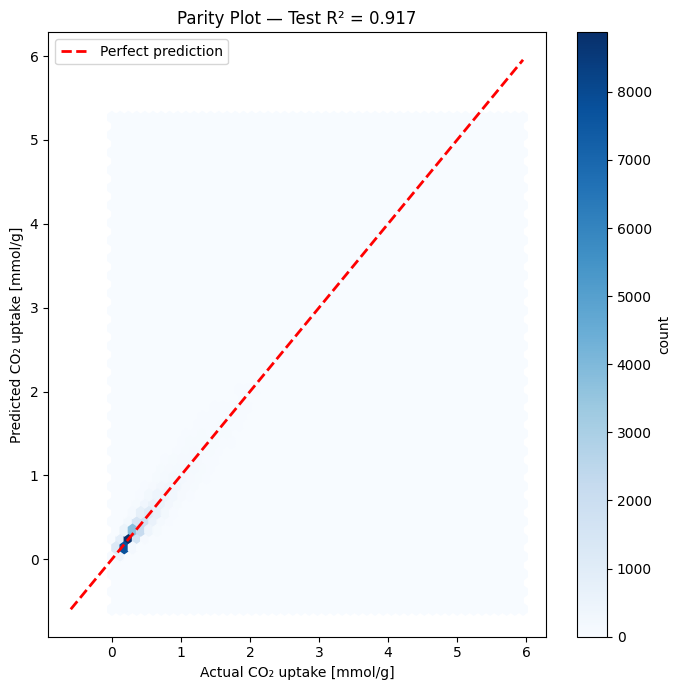

In [34]:
# ── PLOT 8: PARITY PLOT (Hexbin) ─────────────────────────────
from sklearn.metrics import r2_score

y_pred_test = model.predict(X_test)   # skip if already run above

r2_test = r2_score(y_test, y_pred_test)   # ← ADD THIS LINE

plt.figure(figsize=(7, 7))
plt.hexbin(y_test, y_pred_test, gridsize=50, cmap='Blues')
plt.colorbar(label='count')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual CO₂ uptake [mmol/g]')
plt.ylabel('Predicted CO₂ uptake [mmol/g]')
plt.title(f'Parity Plot — Test R² = {r2_test:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=150, bbox_inches='tight')
plt.show()

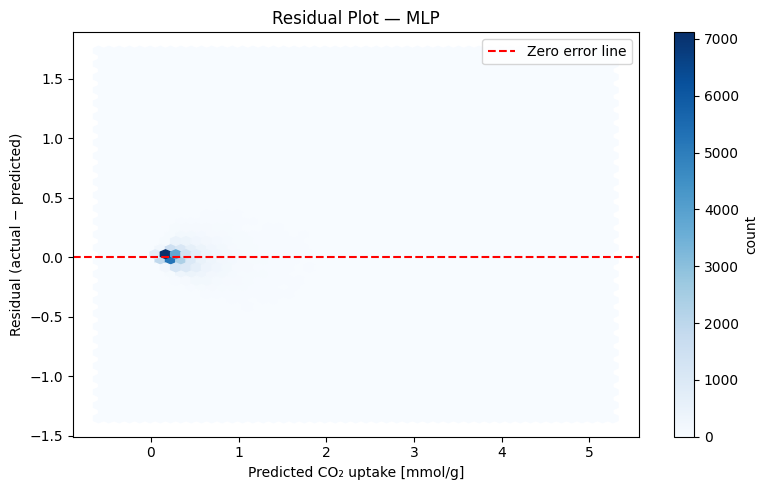

In [28]:
# ── PLOT 9: RESIDUAL PLOT ────────────────────────────────────
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
plt.hexbin(y_pred_test, residuals, gridsize=50, cmap='Blues')
plt.colorbar(label='count')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Zero error line')

plt.xlabel('Predicted CO₂ uptake [mmol/g]')
plt.ylabel('Residual (actual − predicted)')
plt.title('Residual Plot — MLP')
plt.legend()
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

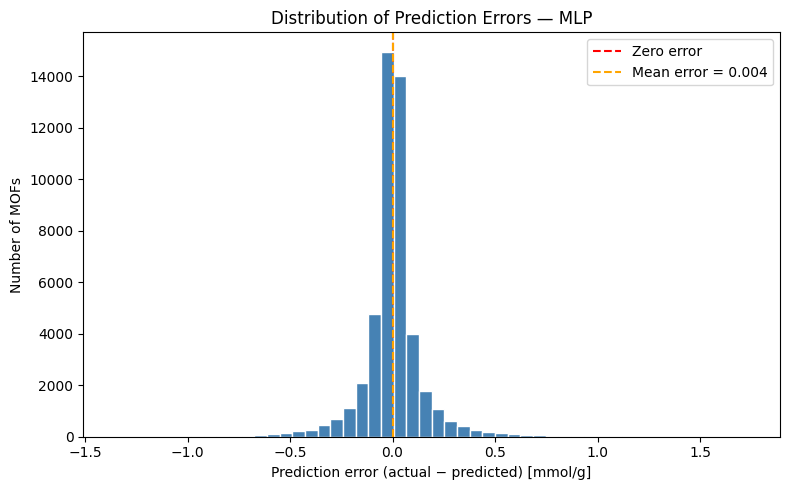

In [29]:
# ── PLOT 10: ERROR DISTRIBUTION ──────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero error')
plt.axvline(residuals.mean(), color='orange', linewidth=1.5, linestyle='--',
            label=f'Mean error = {residuals.mean():.3f}')

plt.xlabel('Prediction error (actual − predicted) [mmol/g]')
plt.ylabel('Number of MOFs')
plt.title('Distribution of Prediction Errors — MLP')
plt.legend()
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Computing permutation importance (this may take ~1-2 minutes)...

Top 10 most important features:
             feature  importance      std
        volume [A^3]    8.733458 0.789446
     organic_linker2    4.177710 0.087700
surface_area [m^2/g]    1.594135 0.059579
       void_fraction    1.545913 0.022148
  CO2/N2_selectivity    0.990208 0.017452
void_volume [cm^3/g]    0.969202 0.069739
          weight [u]    0.435538 0.015048
     organic_linker1    0.308540 0.013538
        topology_nbo    0.233162 0.002333
      metal_linker_9    0.197355 0.009810


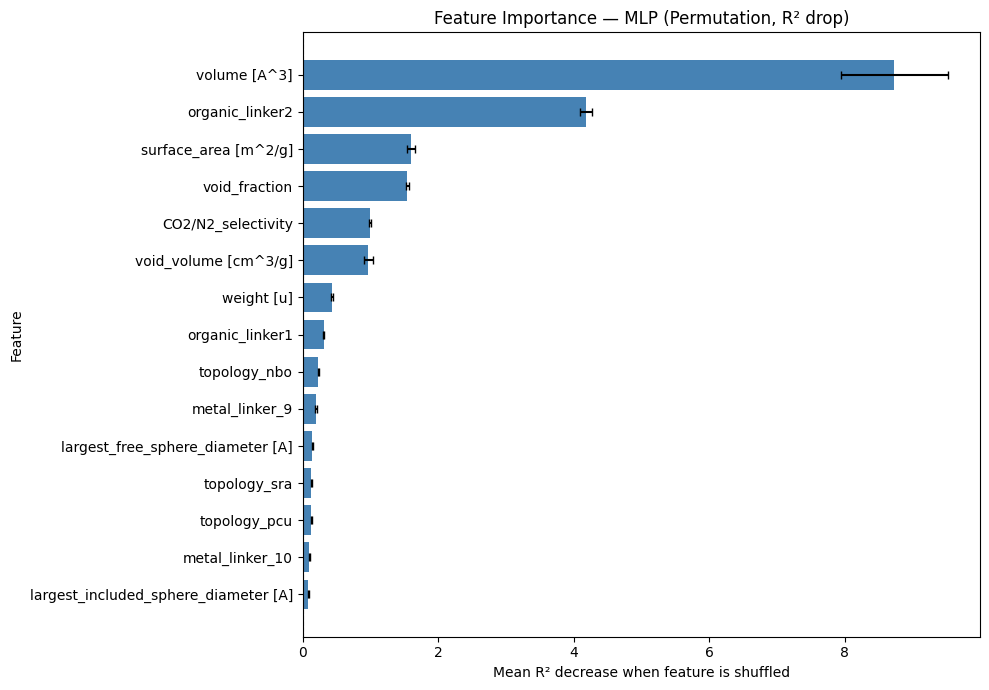

In [32]:
# ── PLOT 11: FEATURE IMPORTANCE via Permutation ───────────────
from sklearn.inspection import permutation_importance  # ← ADD THIS LINE
import numpy as np
import pandas as pd

sample_size = min(5000, X_test.shape[0])
rng = np.random.default_rng(42)
idx = rng.choice(X_test.shape[0], size=sample_size, replace=False)

X_test_sample = X_test[idx]
y_test_sample = y_test.values[idx] if hasattr(y_test, 'values') else y_test[idx]

print("Computing permutation importance (this may take ~1-2 minutes)...")
perm = permutation_importance(
    model, X_test_sample, y_test_sample,
    n_repeats=3, scoring='r2', n_jobs=-1, random_state=42
)

feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 7))
top15 = importance_df.head(15).sort_values('importance')
plt.barh(top15['feature'], top15['importance'],
         xerr=top15['std'], color='steelblue',
         edgecolor='none', capsize=3)
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Feature Importance — MLP (Permutation, R² drop)')
plt.xlabel('Mean R² decrease when feature is shuffled')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

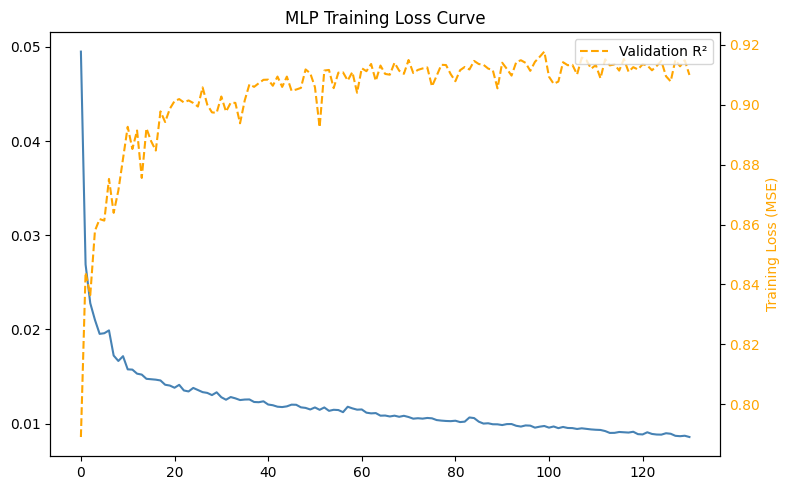


Best validation score : 0.9177
Stopped at iteration  : 131


In [33]:
# ── PLOT 12: TRAINING LOSS CURVE ─────────────────────────────
# MLPRegressor stores the loss at each iteration in .loss_curve_
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_, color='steelblue', linewidth=1.5, label='Training loss')

if hasattr(model, 'validation_scores_') and model.validation_scores_:
    # validation_scores_ exists when early_stopping=True
    # It stores validation score (R²), so we plot it on a twin axis
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    ax2.plot(model.validation_scores_, color='orange',
             linewidth=1.5, linestyle='--', label='Validation R²')
    ax2.set_ylabel('Validation R²', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.legend(loc='center right')

plt.xlabel('Iteration')
plt.ylabel('Training Loss (MSE)')
plt.title('MLP Training Loss Curve')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest validation score : {model.best_validation_score_:.4f}")
print(f"Stopped at iteration  : {model.n_iter_}")